In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd
import json
import itertools
import seaborn as sns
from scipy.interpolate import interp1d,griddata
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [2]:
def interpolateData(x,y,z,nx=200,ny=200,method='linear',
                    fill_value=np.nan,xnew=None,ynew=None):

    if x.min() == x.max() or y.min() == y.max(): # Can not interpolate
        return None,None,None
    elif xnew is None or ynew is None:
        xnew = np.linspace(x.min(),x.max(),nx)
        ynew = np.linspace(y.min(),y.max(),ny)

    xi = np.array([list(v) for v in itertools.product(xnew,ynew)])
    znew = griddata(list(zip(x,y)),z,xi=xi, 
                    method=method,fill_value=fill_value)
    znew = np.reshape(znew,(len(xnew),len(ynew)))
    xnew,ynew  = np.meshgrid(xnew,ynew,indexing='ij')

    return xnew,ynew,znew

### Load data

In [3]:
# Load combined json file (created with collectData.py)
jsonFile = '../ATLAS-SUSY-2018-14_displacedLeptons/atlas_susy_2018_14_HeHe_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfAll = pd.json_normalize(
    data,
    meta=columns
)

### Plot lifetime

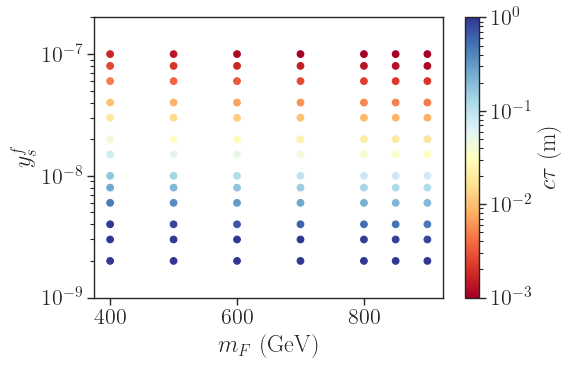

In [4]:
fig = plt.figure(figsize=(6,4))
minxDM = min(dfAll['m5000022']/dfAll['mLLP'])
df = dfAll[dfAll['m5000022']/dfAll['mLLP'] == minxDM]
mn1 = df['mLLP']
y = df['frblock_2']
ctau = df['tau0_ns']*0.3
plt.scatter(mn1,y,c=ctau,cmap=cm,norm=LogNorm(vmin=1e-3,vmax=1.0))
plt.xlabel(r'$m_{F}$ (GeV)')
plt.ylabel(r'$y_s^f$')
plt.yscale('log')
plt.ylim(1e-9,2e-7)
plt.colorbar(label=r'$c \tau$ (m)')
plt.tight_layout()
plt.show()


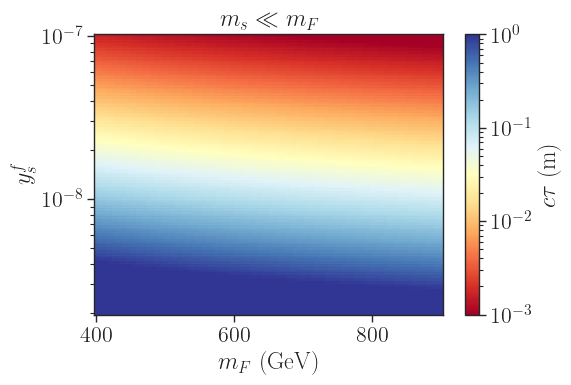

In [5]:
plt.figure(figsize=(6,4))
minxDM = min(dfAll['m5000022']/dfAll['mLLP'])
df = dfAll[dfAll['m5000022']/dfAll['mLLP'] == minxDM]
x = df['mLLP'].to_numpy()
y = np.log10(df['frblock_2'].to_numpy())
z = np.log10(df['tau0_ns'].to_numpy()*0.3)
xnew,ynew,znew = interpolateData(x,y,z,method='linear',nx=100,ny=100)
ynew = 10**ynew
znew = 10**znew

# Use pcolormesh so each color is placed at the actual (x, y) grid point.
# imshow assumes linear pixel spacing and can misplace colors on log-scaled axes.
plt.pcolormesh(
    xnew,
    ynew,
    znew,
    shading='auto',
    cmap=cm,
    norm=LogNorm(vmin=1e-3, vmax=1.0),
)

plt.colorbar(label=r'$c\tau$ (m)')
plt.xlabel(r'$m_{F}$ (GeV)')
plt.ylabel(r'$y_s^f$')
plt.yscale('log')
# plt.ylim(1e-9,2e-7)
plt.tight_layout()
plt.title(r'$m_s \ll m_F$')
plt.savefig('lifetime_mF_vs_y.png')
plt.show()


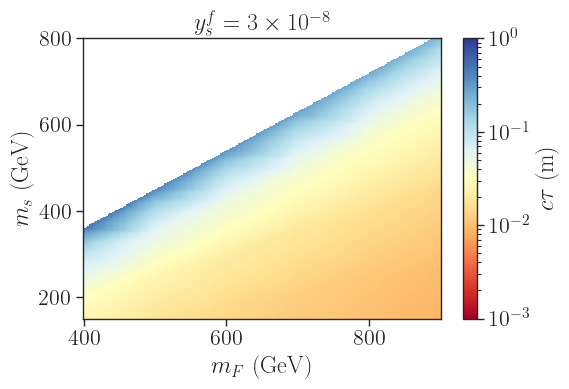

In [6]:
plt.figure(figsize=(6,4))
yfix = 3e-8
df = dfAll[dfAll['frblock_2'] == yfix]
x = df['mLLP'].to_numpy()
y = (df['m5000022']).to_numpy()
z = np.log10(df['tau0_ns'].to_numpy()*0.3)
xnew,ynew,znew = interpolateData(x,y,z,method='linear',nx=300,ny=300)
ynew = ynew
znew = 10**znew

# Use pcolormesh so each color is placed at the actual (x, y) grid point.
# imshow assumes linear pixel spacing and can misplace colors on log-scaled axes.
plt.pcolormesh(
    xnew,
    ynew,
    znew,
    shading='auto',
    cmap=cm,
    norm=LogNorm(vmin=1e-3, vmax=1.0),
)

plt.colorbar(label=r'$c\tau$ (m)')
plt.xlabel(r'$m_{F}$ (GeV)')
plt.ylabel(r'$m_{s}$ (GeV)')
# plt.yscale('log')
plt.ylim(150,800)
plt.tight_layout()
plt.title(r'$y_s^f = 3 \times 10^{-8}$')
plt.savefig('lifetime_mF_vs_ms.png')
plt.show()
